In [1]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
angry_train = np.load('../hybrid/data_train/angry_hybrid_features.npy')
disgust_train = np.load('../hybrid/data_train/disgust_hybrid_features.npy')
fear_train = np.load('../hybrid/data_train/fear_hybrid_features.npy') 
happy_train = np.load('../hybrid/data_train/happy_hybrid_features.npy')
neutral_train = np.load('../hybrid/data_train/neutral_hybrid_features.npy')
sad_train = np.load('../hybrid/data_train/sad_hybrid_features.npy')
suprise_train = np.load('../hybrid/data_train/surprise_hybrid_features.npy')

In [3]:
angry_test = np.load('../hybrid/data_test/angry_hybrid_features.npy')
disgust_test = np.load('../hybrid/data_test/disgust_hybrid_features.npy')
fear_test = np.load('../hybrid/data_test/fear_hybrid_features.npy') 
happy_test = np.load('../hybrid/data_test/happy_hybrid_features.npy')
neutral_test = np.load('../hybrid/data_test/neutral_hybrid_features.npy')
sad_test = np.load('../hybrid/data_test/sad_hybrid_features.npy')
suprise_test = np.load('../hybrid/data_test/surprise_hybrid_features.npy')

In [4]:
train_data = {
    'angry': angry_train,
    'disgust': disgust_train,
    'fear': fear_train,
    'happy': happy_train,
    'neutral': neutral_train,
    'sad': sad_train,
    'suprise': suprise_train
}

In [5]:
test_data = {
    'angry': angry_test,
    'disgust': disgust_test,
    'fear': fear_test,
    'happy': happy_test,
    'neutral': neutral_test,
    'sad': sad_test,
    'suprise': suprise_test
}

In [6]:
train_X_list = []
train_y_list = []

for emotion, data in train_data.items():
    # Reshape each sample from (90, 2) to a flat vector of length 180
    train_X_list.append(data.reshape(data.shape[0], -1))
    # Create an array of labels for the emotion
    train_y_list.append(np.full((data.shape[0],), emotion))


X_train = np.concatenate(train_X_list, axis=0)
y_train = np.concatenate(train_y_list, axis=0)

In [7]:
test_X_list = []
test_y_list = []

for emotion, data in test_data.items():
    test_X_list.append(data.reshape(data.shape[0], -1))
    test_y_list.append(np.full((data.shape[0],), emotion))

X_test = np.concatenate(test_X_list, axis=0)
y_test = np.concatenate(test_y_list, axis=0)

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

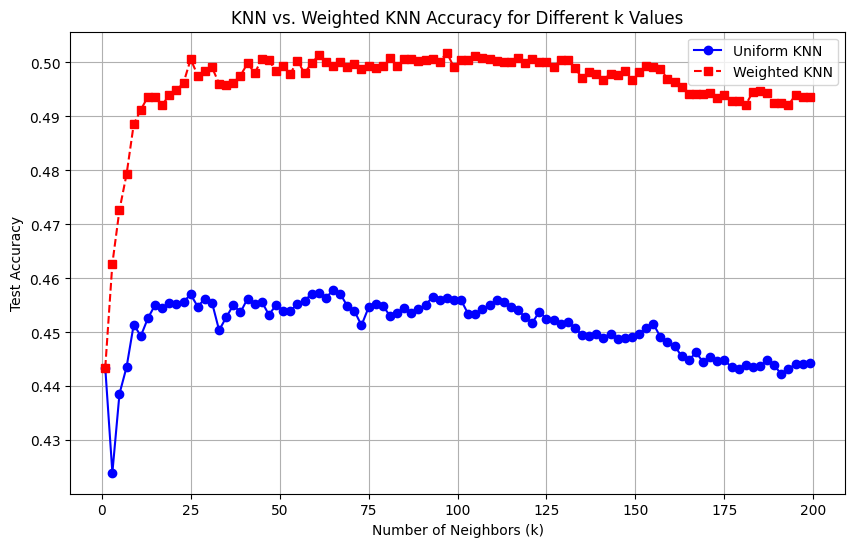

In [34]:

# Test KNN for different values of k
k_values = range(1, 201, 2)  # Odd values from 1 to 100
accuracy_uniform = []
accuracy_weighted = []

for k in k_values:
    # Uniform KNN
    knn_uniform = KNeighborsClassifier(n_neighbors=k, weights="uniform")
    knn_uniform.fit(X_train_scaled, y_train)
    accuracy_uniform.append(knn_uniform.score(X_test_scaled, y_test))

    # Weighted KNN
    knn_weighted = KNeighborsClassifier(n_neighbors=k, weights="distance")
    knn_weighted.fit(X_train_scaled, y_train)
    accuracy_weighted.append(knn_weighted.score(X_test_scaled, y_test))

# Plot accuracy graph
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_uniform, marker='o', linestyle='-', label="Uniform KNN", color='blue')
plt.plot(k_values, accuracy_weighted, marker='s', linestyle='--', label="Weighted KNN", color='red')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Test Accuracy")
plt.title("KNN vs. Weighted KNN Accuracy for Different k Values")
plt.legend()
plt.grid(True)
plt.show()

In [35]:
knn = KNeighborsClassifier(n_neighbors=97, weights="distance")
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=97, weights='distance')

In [36]:
accuracy = knn.score(X_test_scaled, y_test)
print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.5018094089264173
